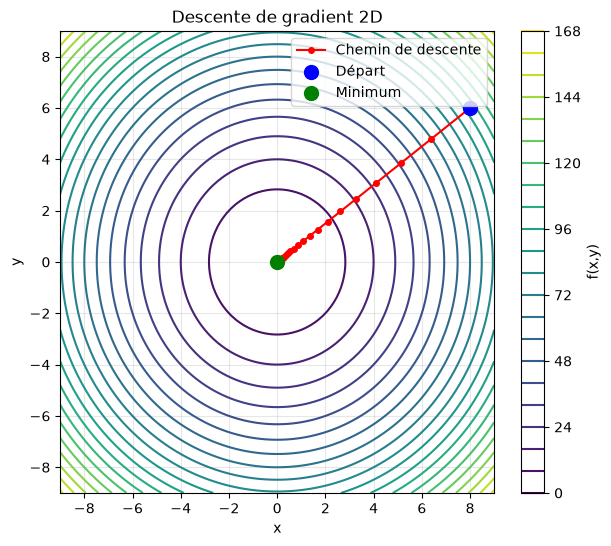

Point final : x=0.000114, y=0.000086


In [4]:
# Descente de gradient sur f(x,y) = x² + y²

def f(x, y):
    return x**2 + y**2

def gradient_f(x, y):
    return np.array([2*x, 2*y])

# Paramètres
x, y = 8.0, 6.0      # point de départ
learning_rate = 0.1
n_iterations = 50

historique = [(x, y)]

for i in range(n_iterations):
    grad = gradient_f(x, y)
    x = x - learning_rate * grad[0]
    y = y - learning_rate * grad[1]
    historique.append((x, y))

# Visualisation
hx = [p[0] for p in historique]
hy = [p[1] for p in historique]

x_plot = np.linspace(-9, 9, 100)
y_plot = np.linspace(-9, 9, 100)
X, Y = np.meshgrid(x_plot, y_plot)
Z = f(X, Y)

plt.figure(figsize=(7, 6))
plt.contour(X, Y, Z, levels=20, cmap="viridis")
plt.colorbar(label="f(x,y)")
plt.plot(hx, hy, "r-o", markersize=4, label="Chemin de descente")
plt.scatter([8], [6], color="blue", s=100, zorder=5, label="Départ")
plt.scatter([0], [0], color="green", s=100, zorder=5, label="Minimum")
plt.legend()
plt.title("Descente de gradient 2D")
plt.xlabel("x"); plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Point final : x={x:.6f}, y={y:.6f}")

In [3]:
# Le gradient = dérivée généralisée pour les fonctions à plusieurs variables
# C'est un vecteur de toutes les dérivées partielles
# 
# Exemple : f(x, y) = x² + y²
# ∂f/∂x = 2x  (dérivée par rapport à x, y fixe)
# ∂f/∂y = 2y  (dérivée par rapport à y, x fixe)
# gradient = [2x, 2y]

def f(x, y):
    return x**2 + y**2

def gradient_f(x, y):
    df_dx = 2*x
    df_dy = 2*y
    return np.array([df_dx, df_dy])

# Calculer le gradient en différents points
points = [(3, 4), (1, 0), (0, 0), (-2, 3)]

for (x, y) in points:
    grad = gradient_f(x, y)
    print(f"Point ({x}, {y}) → f={f(x,y)} → gradient={grad}")

print("\nEn (0,0) le gradient est [0,0] → c'est le minimum !")

Point (3, 4) → f=25 → gradient=[6 8]
Point (1, 0) → f=1 → gradient=[2 0]
Point (0, 0) → f=0 → gradient=[0 0]
Point (-2, 3) → f=13 → gradient=[-4  6]

En (0,0) le gradient est [0,0] → c'est le minimum !


Point de départ : x=8.0, f(x)=64.0
Point final     : x=0.000114, f(x)=0.000000
Minimum réel    : x=0, f(x)=0


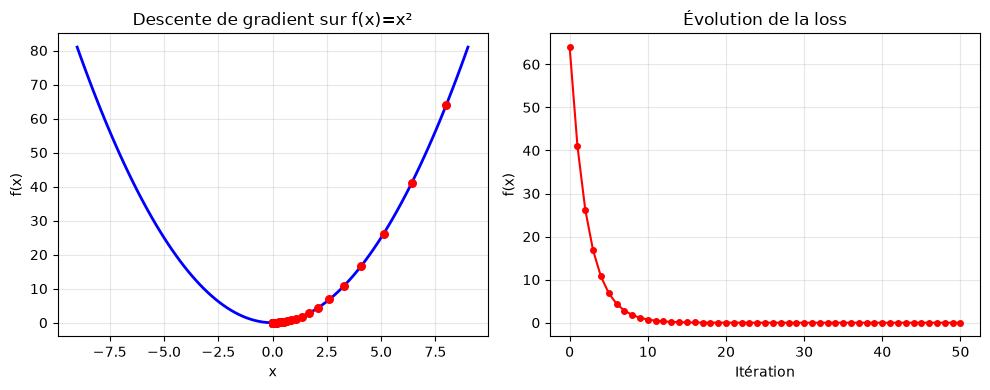

In [2]:
# Descente de gradient — trouver le minimum de f(x) = x²
# Algorithme : x = x - learning_rate * f'(x)

def f(x):
    return x**2

def f_prime(x):
    return 2*x

# Paramètres
x = 8.0          # point de départ
learning_rate = 0.1
n_iterations = 50

historique_x = [x]
historique_f = [f(x)]

# Boucle de descente
for i in range(n_iterations):
    gradient = f_prime(x)
    x = x - learning_rate * gradient
    historique_x.append(x)
    historique_f.append(f(x))

print(f"Point de départ : x=8.0, f(x)={f(8.0)}")
print(f"Point final     : x={x:.6f}, f(x)={f(x):.6f}")
print(f"Minimum réel    : x=0, f(x)=0")

# Visualisation
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
x_plot = np.linspace(-9, 9, 100)
plt.plot(x_plot, f(x_plot), "b-", linewidth=2)
plt.scatter(historique_x, historique_f, c="red", s=30, zorder=5)
plt.title("Descente de gradient sur f(x)=x²")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(historique_f, "r-o", markersize=4)
plt.title("Évolution de la loss")
plt.xlabel("Itération"); plt.ylabel("f(x)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Matplotlib is building the font cache; this may take a moment.


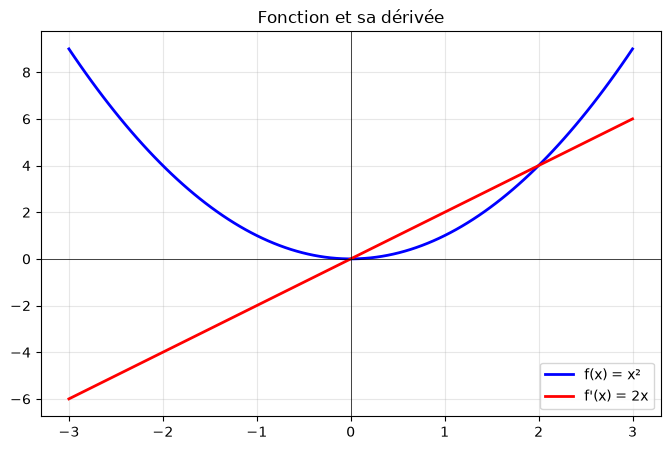

f'(x=2) = 4
f'(x=0) = 0


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# La dérivée mesure le taux de changement d'une fonction
# f'(x) = combien f(x) change quand x change d'un tout petit peu

# Exemple : f(x) = x²
# Dérivée théorique : f'(x) = 2x

x = np.linspace(-3, 3, 100)  # 100 points entre -3 et 3
f = x**2                      # f(x) = x²
f_prime = 2*x                 # f'(x) = 2x

plt.figure(figsize=(8, 5))
plt.plot(x, f, label="f(x) = x²", color="blue", linewidth=2)
plt.plot(x, f_prime, label="f'(x) = 2x", color="red", linewidth=2)
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.legend()
plt.title("Fonction et sa dérivée")
plt.grid(True, alpha=0.3)
plt.show()

print("f'(x=2) =", 2*2)   # pente en x=2
print("f'(x=0) =", 2*0)   # pente en x=0 → minimum !

=== RÈGLE DE LA CHAÎNE ===
h(x) = (3x + 2)²
h'(x) = 6(3x + 2)

En x=2 :
h'(2) théorique  : 48.000000
h'(2) numérique  : 48.000000
→ Identiques ✅

=== BACKPROPAGATION DANS UN RÉSEAU ===

Réseau simple : x → [couche1] → a1 → [couche2] → a2 → Loss

Forward pass :
  a1 = relu(w1 × x + b1)
  a2 = sigmoid(w2 × a1 + b2)
  L  = -y × log(a2) - (1-y) × log(1-a2)

Backward pass (règle de la chaîne) :
  dL/dw2 = dL/da2 × da2/dw2
  dL/dw1 = dL/da2 × da2/da1 × da1/dw1

Accuracy après 100 epochs : 0.9400


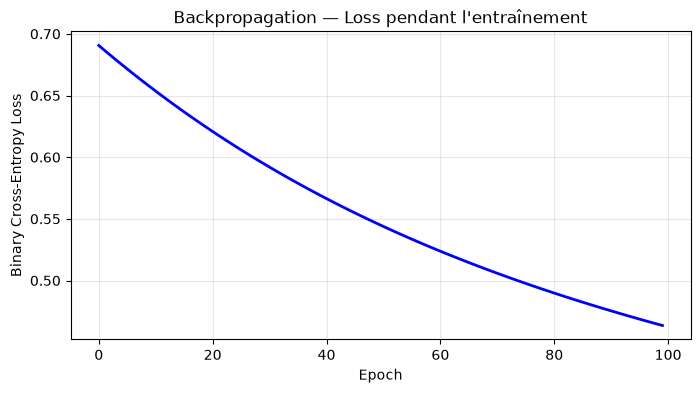

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# RÈGLE DE LA CHAÎNE — LA BASE DE LA BACKPROPAGATION
# Si h(x) = f(g(x)), alors h'(x) = f'(g(x)) × g'(x)

# Exemple simple
# h(x) = (3x + 2)²
# g(x) = 3x + 2     → g'(x) = 3
# f(u) = u²         → f'(u) = 2u
# h'(x) = f'(g(x)) × g'(x) = 2(3x+2) × 3 = 6(3x+2)

def h(x):
    return (3*x + 2)**2

def h_prime_theorique(x):
    return 6*(3*x + 2)

# Vérification numérique
x = 2.0
epsilon = 1e-5
h_prime_numerique = (h(x + epsilon) - h(x - epsilon)) / (2 * epsilon)

print("=== RÈGLE DE LA CHAÎNE ===")
print(f"h(x) = (3x + 2)²")
print(f"h'(x) = 6(3x + 2)")
print(f"\nEn x=2 :")
print(f"h'(2) théorique  : {h_prime_theorique(2):.6f}")
print(f"h'(2) numérique  : {h_prime_numerique:.6f}")
print(f"→ Identiques ✅")

print("\n=== BACKPROPAGATION DANS UN RÉSEAU ===")
print("""
Réseau simple : x → [couche1] → a1 → [couche2] → a2 → Loss

Forward pass :
  a1 = relu(w1 × x + b1)
  a2 = sigmoid(w2 × a1 + b2)
  L  = -y × log(a2) - (1-y) × log(1-a2)

Backward pass (règle de la chaîne) :
  dL/dw2 = dL/da2 × da2/dw2
  dL/dw1 = dL/da2 × da2/da1 × da1/dw1
""")

# Implémentation manuelle d'un réseau 1 couche
# pour voir la backprop en action

np.random.seed(42)
n_samples = 100
X = np.random.randn(n_samples, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(float)

# Initialisation
w = np.random.randn(2) * 0.01
b = 0.0
lr = 0.1

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

losses = []
for epoch in range(100):
    # FORWARD PASS
    z = X @ w + b
    a = sigmoid(z)
    loss = -np.mean(y * np.log(a + 1e-8) + (1-y) * np.log(1-a + 1e-8))
    losses.append(loss)
    
    # BACKWARD PASS (règle de la chaîne)
    dL_da = (a - y) / n_samples        # dL/da
    dL_dz = dL_da * a * (1 - a)       # da/dz = sigmoid'(z)
    dL_dw = X.T @ dL_dz               # dz/dw = X
    dL_db = np.sum(dL_dz)             # dz/db = 1
    
    # UPDATE
    w -= lr * dL_dw
    b -= lr * dL_db

# Résultats
predictions = (sigmoid(X @ w + b) > 0.5).astype(int)
accuracy = np.mean(predictions == y)

print(f"Accuracy après 100 epochs : {accuracy:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(losses, color="blue", linewidth=2)
plt.title("Backpropagation — Loss pendant l'entraînement")
plt.xlabel("Epoch"); plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True, alpha=0.3)
plt.show()